# Load data and train/test split

Everyone uses this. Run these cells first.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
import matplotlib.pyplot as plt

df = pd.read_parquet("combined_preprocessed_weather.parquet")
print(df.shape)


(6898737, 28)


In [2]:
df["IS_HOLIDAY"] = df["IS_HOLIDAY"].astype("category")
df["WX_CODE"] = df["WX_CODE"].astype("int64")
df["WX_CLDC"] = df["WX_CLDC"].astype("int64")
df["WX_RHUM"] = df["WX_RHUM"].astype("int64")


In [3]:
# Drop leakage columns (only known AFTER the flight — kept in preprocessed for EDA only)
postprocessing_cols = [
    "DEP_DELAY",
    "DEP_DEL15",
    "CARRIER_DELAY",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "OP_UNIQUE_CARRIER",
    "DAY_OF_MONTH",
]

X = df.drop(
    columns=[c for c in postprocessing_cols + ["DELAY_CLASS"] if c in df.columns]
)
X["DEP_HOUR"] = X["DEP_HOUR"].replace(24, 0)
y = df["DELAY_CLASS"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Class distribution — train:")
print(y_train.value_counts(normalize=True).sort_index())
print(y_test.value_counts(normalize=True).sort_index())


Train: (5518989, 18), Test: (1379748, 18)
Class distribution — train:
DELAY_CLASS
0    0.782692
1    0.168084
2    0.049224
Name: proportion, dtype: float64
DELAY_CLASS
0    0.782692
1    0.168084
2    0.049224
Name: proportion, dtype: float64


In [4]:
X.dtypes


MONTH                   int64
DAY_OF_WEEK             int64
CRS_ELAPSED_TIME      float64
DISTANCE              float64
ORIGIN_STATE           object
DEST_STATE             object
DEP_HOUR                int64
PREV_FLIGHT_DELAY     float64
HAS_PREV_FLIGHT         int64
AIRPORT_TRAFFIC         int64
IS_HOLIDAY           category
WX_TEMP               Float64
WX_RHUM                 int64
WX_PRCP               Float64
WX_WSPD               Float64
WX_PRES               Float64
WX_CLDC                 int64
WX_CODE                 int64
dtype: object

### Data Scaling + One Hot Encoding run THIS

In [5]:
time_vars = ["MONTH", "DAY_OF_WEEK", "DEP_HOUR"]


In [6]:
from sklearn.preprocessing import FunctionTransformer


def circular_transform(X, period):
    X = np.array(X, dtype=float)
    sin_vals = np.sin(2 * np.pi * X / period)
    cos_vals = np.cos(2 * np.pi * X / period)
    return np.column_stack([sin_vals, cos_vals])


def circular_feature_names(_, input_features):
    return [f"{c}_sin" for c in input_features] + [f"{c}_cos" for c in input_features]


hour_transform = FunctionTransformer(
    circular_transform,
    kw_args={"period": 24},
    feature_names_out=circular_feature_names,
)
day_transform = FunctionTransformer(
    circular_transform,
    kw_args={"period": 7},
    feature_names_out=circular_feature_names,
)
month_transform = FunctionTransformer(
    circular_transform,
    kw_args={"period": 12},
    feature_names_out=circular_feature_names,
)


In [7]:
numeric_features = X_train.select_dtypes(include=["int8", "int16", "int32", "int64", "float16", "float32", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns

numeric_features = [feature for feature in numeric_features if feature not in time_vars]
categorical_features = [feature for feature in categorical_features if feature not in time_vars]

In [8]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


preprocessor = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("dep_hour_circ", hour_transform, ["DEP_HOUR"]),
        ("month_cirl", hour_transform, ["MONTH"]),
        ("day_circ", hour_transform, ["DAY_OF_WEEK"])
    ]
)
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)
print(f"Encoded shapes — train: {X_train_preprocessed.shape}, test: {X_test_preprocessed.shape}")


Encoded shapes — train: (5518989, 126), test: (1379748, 126)


## Undersampling Algorithm

In [9]:
# from imblearn.combine import SMOTETomek
# from imblearn.under_sampling import RandomUnderSampler, TomekLinks
# from imblearn.pipeline import Pipeline as ImbPipeline

# undersample_pipe = ImbPipeline([
#     ('rus', RandomUnderSampler(random_state=42, sampling_strategy={0: 542_000, 1: 542_000, 2: 271_000})),
#     ('tomek', TomekLinks(sampling_strategy='not minority')),
# ])

# X_train_bal, y_train_bal = undersample_pipe.fit_resample(X_train_preprocessed, y_train)

In [10]:
# print(X_train_bal.shape)
# print(y_train_bal.value_counts(normalize=True).sort_index())

In [11]:
# combined_xy = np.hstack((X_train_bal, y_train_bal.values.reshape(-1, 1)))
# combined = pd.DataFrame(combined_xy, columns=[f"feature_{i}" for i in range(X_train_bal.shape[1])] + ["DELAY_CLASS"])
# combined.to_parquet("undersampled.parquet", index=False)

# Helper function so everyone reports the same metrics.

In [12]:
CLASS_NAMES = ['On-time (<15 min)', 'Moderate (15-89 min)', 'Severe (90+ min)']

def evaluate(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    print(f"--- {name} ---")
    print(f"Accuracy:      {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision (w): {precision_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"Recall (w):    {recall_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"F1 (w):        {f1_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"F1 (macro):    {f1_score(y_test, y_pred, average='macro', zero_division=0):.4f}  ← primary metric for imbalanced multiclass")
    print(f"Precision (m): {precision_score(y_test, y_pred, average='macro', zero_division=0):.4f}")
    print(f"Recall (m):    {recall_score(y_test, y_pred, average='macro', zero_division=0):.4f}")
    print(f"AUC-ROC:       {roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted'):.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(cm, cmap="Blues")
    for i in range(len(CLASS_NAMES)):
        for j in range(len(CLASS_NAMES)):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=10)
    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_yticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{name} — Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 (macro)": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "Precision (macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1 (weighted)": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "AUC-ROC": roc_auc_score(y_test, y_prob, multi_class="ovr", average="weighted"),
    }


In [13]:
results = []


**most difficult task -- what features should we use??**

**what features we should drop?? one by one**

**and then, One-hot encoding so that we can add the destination in there**

---
# Sam — Logistic Regression

In [14]:
undersampled = pd.read_parquet("undersampled.parquet")
X_train_us = undersampled.drop(columns=["DELAY_CLASS"]).values
y_train_us = undersampled["DELAY_CLASS"].astype(int).reset_index(drop=True)
print(f"Training: {X_train_us.shape}  classes: {y_train_us.value_counts().sort_index().to_dict()}")


Training: (1031455, 126)  classes: {0: 390021, 1: 370434, 2: 271000}


--- Logistic Regression ---
Accuracy:      0.7128
Precision (w): 0.7800
Recall (w):    0.7128
F1 (w):        0.7365
F1 (macro):    0.5542  ← primary metric for imbalanced multiclass
Precision (m): 0.5495
Recall (m):    0.5841
AUC-ROC:       0.7857

                      precision    recall  f1-score   support

   On-time (<15 min)       0.90      0.76      0.82   1079918
Moderate (15-89 min)       0.34      0.58      0.43    231913
    Severe (90+ min)       0.41      0.41      0.41     67917

            accuracy                           0.71   1379748
           macro avg       0.55      0.58      0.55   1379748
        weighted avg       0.78      0.71      0.74   1379748



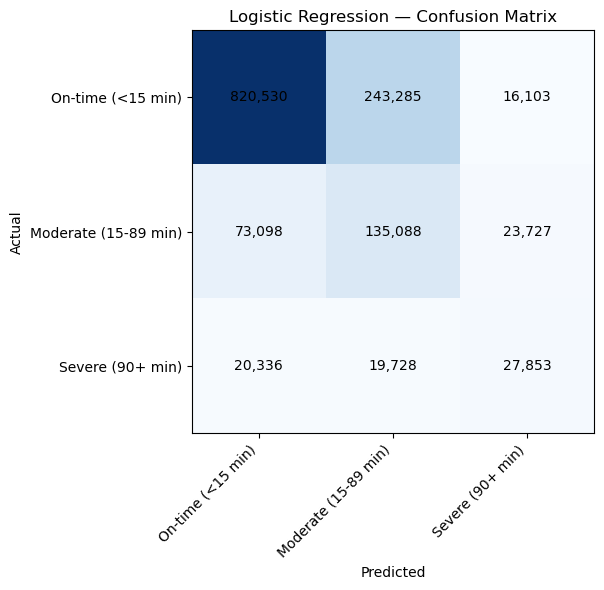

In [15]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    solver="saga",
    max_iter=200,
    random_state=42,
    n_jobs=-1,
)
lr_model.fit(X_train_us, y_train_us)

results.append(evaluate("Logistic Regression", lr_model, X_test_preprocessed, y_test))


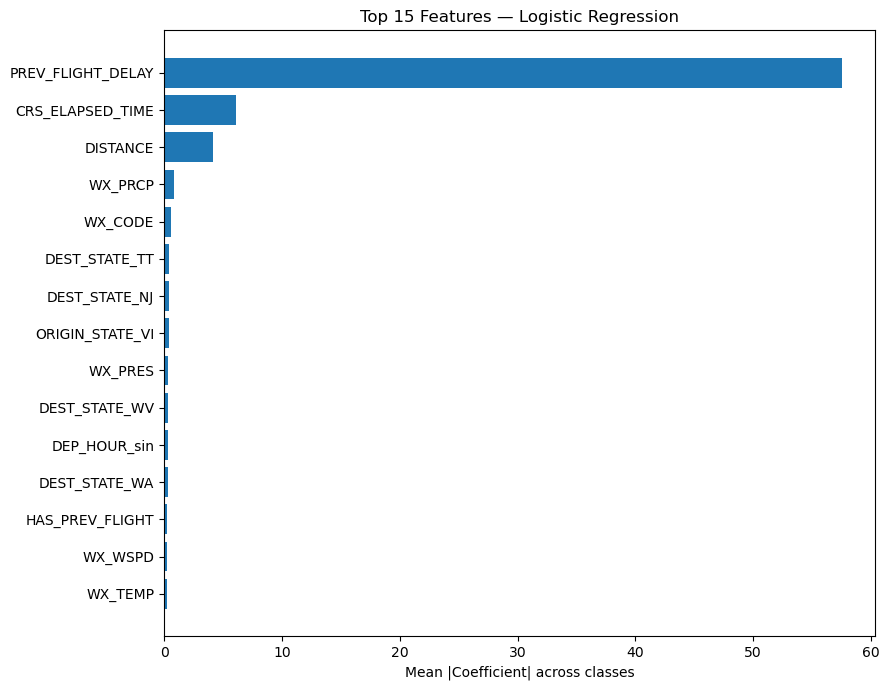

In [16]:
feature_names = [n.split("__", 1)[-1] for n in preprocessor.get_feature_names_out()]
mean_abs_coef = np.abs(lr_model.coef_).mean(axis=0)

coef_df = pd.DataFrame({
    "feature": feature_names,
    "importance": mean_abs_coef,
}).nlargest(15, "importance").sort_values("importance")

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(coef_df["feature"], coef_df["importance"], color="#1f77b4")
ax.set_xlabel("Mean |Coefficient| across classes")
ax.set_title("Top 15 Features — Logistic Regression")
plt.tight_layout()
plt.show()


---
# Wahid — Random Forest

--- Random Forest ---
Accuracy:      0.7592
Precision (w): 0.8022
Recall (w):    0.7592
F1 (w):        0.7741
F1 (macro):    0.6064  ← primary metric for imbalanced multiclass
Precision (m): 0.6140
Recall (m):    0.6212
AUC-ROC:       0.8123

                      precision    recall  f1-score   support

   On-time (<15 min)       0.90      0.81      0.85   1079918
Moderate (15-89 min)       0.41      0.63      0.50    231913
    Severe (90+ min)       0.53      0.42      0.47     67917

            accuracy                           0.76   1379748
           macro avg       0.61      0.62      0.61   1379748
        weighted avg       0.80      0.76      0.77   1379748



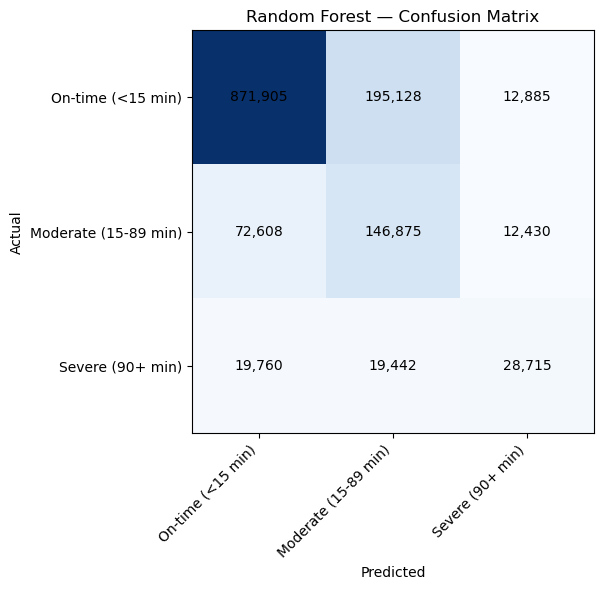

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train_us, y_train_us)

results.append(evaluate("Random Forest", rf_model, X_test_preprocessed, y_test))


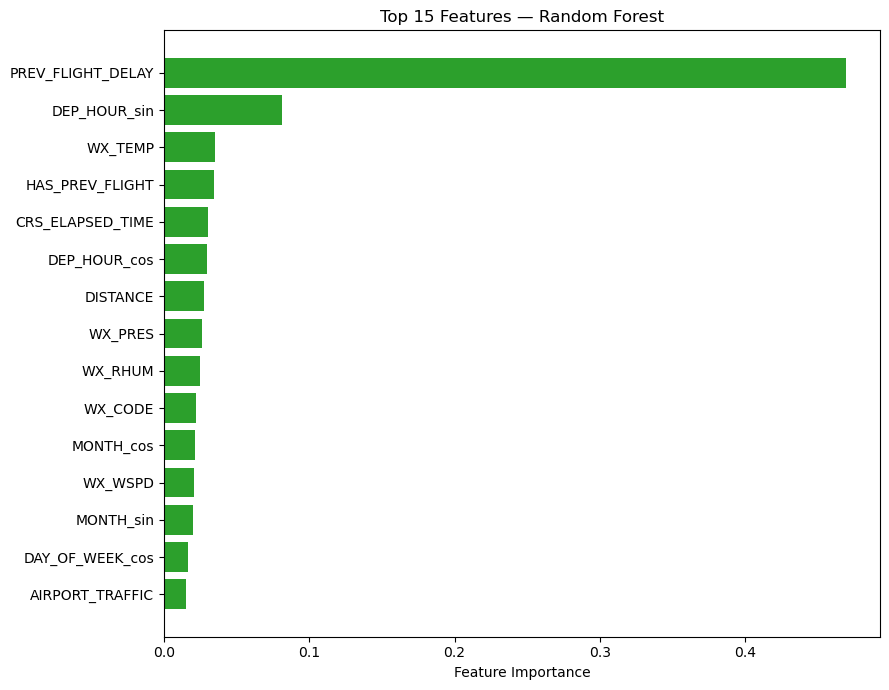

In [18]:
feature_names = [n.split("__", 1)[-1] for n in preprocessor.get_feature_names_out()]
imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_,
}).nlargest(15, "importance").sort_values("importance")

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(imp_df["feature"], imp_df["importance"], color="#2ca02c")
ax.set_xlabel("Feature Importance")
ax.set_title("Top 15 Features — Random Forest")
plt.tight_layout()
plt.show()


---
# Aryan — XGBoost

--- XGBoost ---
Accuracy:      0.7709
Precision (w): 0.8006
Recall (w):    0.7709
F1 (w):        0.7824
F1 (macro):    0.6017  ← primary metric for imbalanced multiclass
Precision (m): 0.5873
Recall (m):    0.6256
AUC-ROC:       0.8157

                      precision    recall  f1-score   support

   On-time (<15 min)       0.90      0.83      0.86   1079918
Moderate (15-89 min)       0.44      0.60      0.51    231913
    Severe (90+ min)       0.42      0.45      0.43     67917

            accuracy                           0.77   1379748
           macro avg       0.59      0.63      0.60   1379748
        weighted avg       0.80      0.77      0.78   1379748



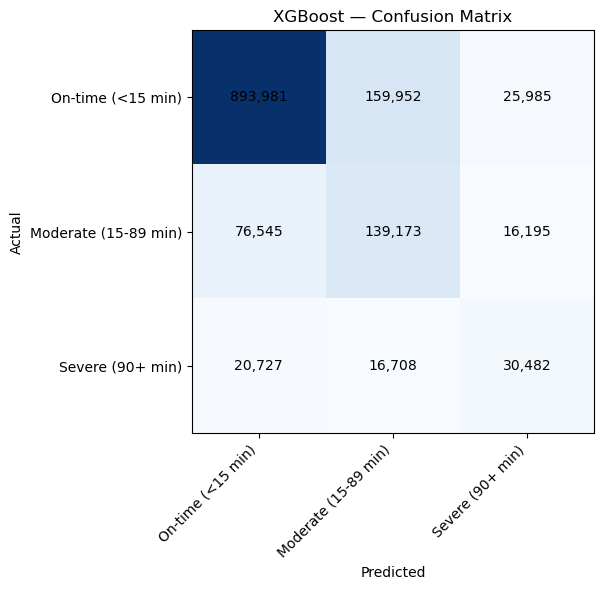

In [19]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    max_depth=5,
    learning_rate=0.2,
    n_estimators=100,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
)
xgb_model.fit(X_train_us, y_train_us.values, verbose=False)

results.append(evaluate("XGBoost", xgb_model, X_test_preprocessed, y_test))


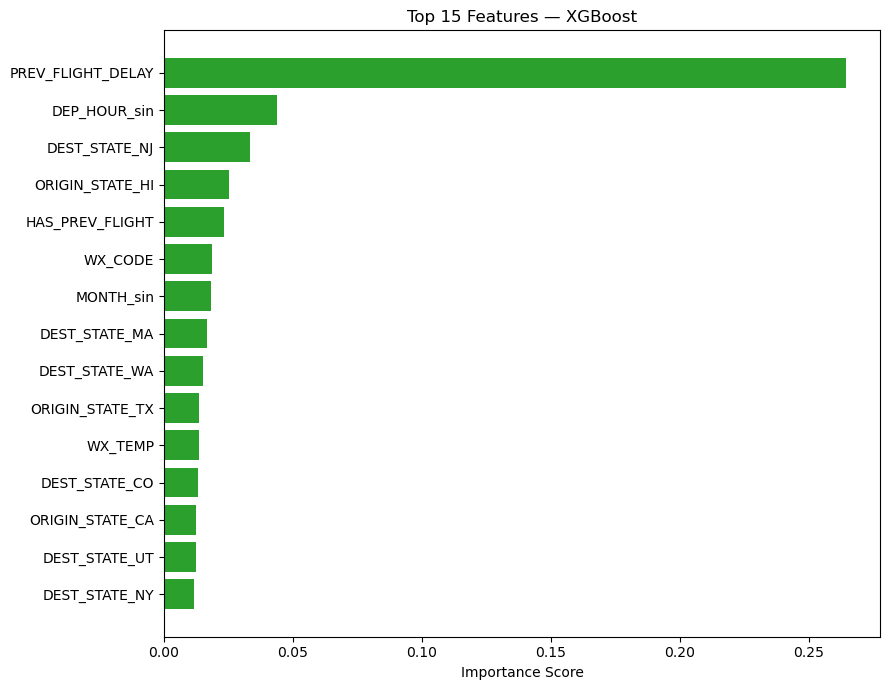

In [20]:
importances = xgb_model.feature_importances_
feature_names = [n.split("__", 1)[-1] for n in preprocessor.get_feature_names_out()]

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
}).nlargest(15, "importance").sort_values("importance")

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(importance_df["feature"], importance_df["importance"], color="#2ca02c")
ax.set_xlabel("Importance Score")
ax.set_title("Top 15 Features — XGBoost")
plt.tight_layout()
plt.show()


---
# Dennis — Naive Bayes

## Naive Bayes

In [21]:
from sklearn.preprocessing import OrdinalEncoder


def pipeline(data, encoder=None):

    cat_cols_idx = []
    for col_idx, col in enumerate(data.columns):
        if col != "DISTANCE":
            cat_cols_idx.append(col_idx)

    if encoder is None:
        encoder = OrdinalEncoder(dtype=int)
        data.iloc[:, cat_cols_idx] = encoder.fit_transform(data.iloc[:, cat_cols_idx])
    else:
        data.iloc[:, cat_cols_idx] = encoder.transform(data.iloc[:, cat_cols_idx])

    data = data.apply(pd.to_numeric)

    return data, encoder


In [22]:
df_nb = pd.read_parquet("combined_preprocessed.parquet")

leak_cols = [
    "DEP_DELAY",
    "ARR_DELAY",
    "DEP_DEL15",
    "CARRIER_DELAY",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "DIVERTED",
    "DEST_AIRPORT_SEQ_ID",
]
X_nb = df_nb.drop(columns=[c for c in leak_cols + ["DELAY_CLASS"] if c in df_nb.columns])
X_nb["DEP_HOUR"] = X_nb["DEP_HOUR"].replace(24, 0)

y_nb = df_nb["DELAY_CLASS"]

X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_nb,
    y_nb,
    test_size=0.2,
    random_state=42,
    stratify=y_nb,
)


In [23]:
from sklearn.preprocessing import OrdinalEncoder

NUMERIC_COLS = {"DISTANCE", "CRS_ELAPSED_TIME", "PREV_FLIGHT_DELAY"}

encoder = OrdinalEncoder(
    dtype=int, handle_unknown="use_encoded_value", unknown_value=-1
)
cat_cols = [col for col in X_nb.columns if col not in NUMERIC_COLS]
encoder.fit(X_nb[cat_cols])

PER_CLASS = 100_000
min_count = min(y_train_nb.value_counts().min(), PER_CLASS)
X_train_bal = (
    X_train_nb.groupby(y_train_nb, group_keys=False)
    .apply(lambda x: x.sample(min_count, random_state=42))
    .reset_index(drop=True)
)
y_train_bal = (
    y_train_nb.groupby(y_train_nb, group_keys=False)
    .apply(lambda x: x.sample(min_count, random_state=42))
    .reset_index(drop=True)
)


def nb_pipeline(data, encoder):
    data = data.copy()
    cat_cols_idx = [i for i, col in enumerate(data.columns) if col not in NUMERIC_COLS]
    data.iloc[:, cat_cols_idx] = encoder.transform(data.iloc[:, cat_cols_idx])
    return data.apply(pd.to_numeric)


X_train_bal = nb_pipeline(X_train_bal, encoder)
X_test_nb = nb_pipeline(X_test_nb, encoder)
print(f"NB train size: {len(X_train_bal):,} ({min_count:,} per class)")


NB train size: 300,000 (100,000 per class)


In [24]:
X_train_bal.head()


,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,CRS_ELAPSED_TIME,DISTANCE,ORIGIN_STATE,DEST_STATE,DEP_HOUR,PREV_FLIGHT_DELAY,HAS_PREV_FLIGHT,AIRPORT_TRAFFIC,IS_HOLIDAY
0,2,12,3,11,127.0,602.0,5,3,11,-37.0,1,9,0
1,2,19,3,9,108.0,406.0,7,29,14,-20.0,1,9,0
2,9,12,0,12,60.0,159.0,19,46,19,16.0,1,8,1
3,1,3,1,13,141.0,645.0,30,14,11,-31.0,1,8,0
4,11,25,4,12,80.0,407.0,44,35,14,-4.0,1,9,1


In [25]:
from mixed_naive_bayes import MixedNB

cat_cols_idx = [i for i, col in enumerate(X_train_bal.columns) if col not in NUMERIC_COLS]

nb_clf = MixedNB(categorical_features=cat_cols_idx)
nb_clf.fit(X_train_bal, y_train_bal)


MixedNB(alpha=0.5, var_smoothing=1e-09)

--- Naive Bayes ---
Accuracy:      0.7340
Precision (w): 0.7751
Recall (w):    0.7340
F1 (w):        0.7500
F1 (macro):    0.5610  ← primary metric for imbalanced multiclass
Precision (m): 0.5547
Recall (m):    0.5795
AUC-ROC:       0.7641

                      precision    recall  f1-score   support

   On-time (<15 min)       0.89      0.80      0.84   1079918
Moderate (15-89 min)       0.36      0.53      0.43    231913
    Severe (90+ min)       0.42      0.41      0.41     67917

            accuracy                           0.73   1379748
           macro avg       0.55      0.58      0.56   1379748
        weighted avg       0.78      0.73      0.75   1379748



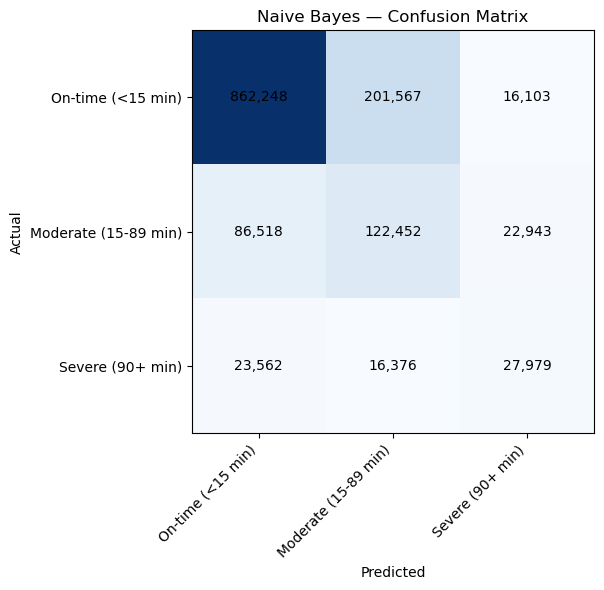

In [26]:
results.append(evaluate(name='Naive Bayes', model=nb_clf, X_test=X_test_nb, y_test=y_test_nb))


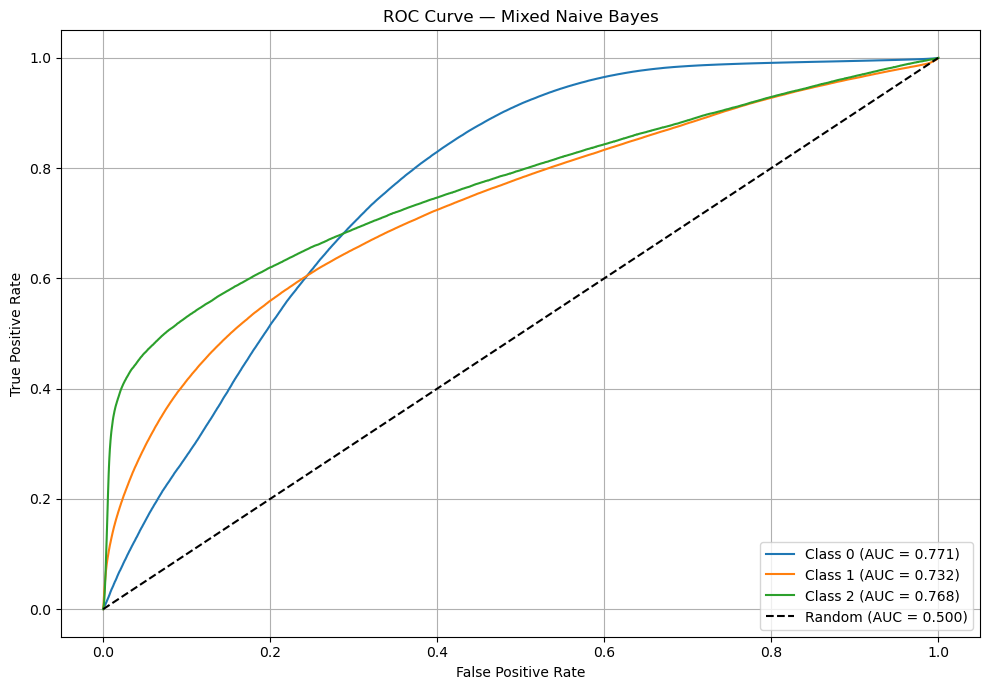

In [27]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_proba = nb_clf.predict_proba(X_test_nb)

classes = np.unique(y_test_nb)
y_test_bin = label_binarize(y_test_nb, classes=classes)

plt.figure(figsize=(10, 7))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {cls} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Mixed Naive Bayes")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


---
# Aryan - RNN
Requires specific version `pip install tensorflow==2.18.0`

In [28]:
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

scaler = StandardScaler()
X_train_rnn = scaler.fit_transform(X_train_us)
X_test_rnn = scaler.transform(X_test_preprocessed)

X_train_rnn = X_train_rnn.reshape(X_train_rnn.shape[0], 1, X_train_rnn.shape[1])
X_test_rnn = X_test_rnn.reshape(X_test_rnn.shape[0], 1, X_test_rnn.shape[1])

print(f"RNN train shape: {X_train_rnn.shape}, test shape: {X_test_rnn.shape}")


RNN train shape: (1031455, 1, 126), test shape: (1379748, 1, 126)


In [29]:
rnn_model = Sequential([
    SimpleRNN(64, activation='relu', input_shape=(1, X_train_rnn.shape[2])),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

rnn_model.fit(
    X_train_rnn,
    y_train_us.values,
    epochs=30,
    batch_size=1024,
    validation_split=0.1,
    verbose=1
)


/Users/wahidhashem/miniforge3/envs/msds/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
907/907 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6089 - loss: 0.8843 - val_accuracy: 0.3433 - val_loss: 1.3646
Epoch 2/30
907/907 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6691 - loss: 0.7934 - val_accuracy: 0.3713 - val_loss: 1.3596
Epoch 3/30
907/907 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6751 - loss: 0.7766 - val_accuracy: 0.3730 - val_loss: 1.2884
Epoch 4/30
907/907 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6771 - loss: 0.7717 - val_accuracy: 0.3561 - val_loss: 1.3562
Epoch 5/30
907/907 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6779 - loss: 0.7685 - val_accuracy: 0.3687 - val_loss: 1.2546
Epoch 6/30
907/907 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6785 - loss: 0.7670 - val_accuracy: 0.3655 - val_loss: 1.3017
Epoch 7/30
907/907 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6789 - loss: 0.7657 - val_accuracy: 0.3728 - val_loss: 1.2731
Epoch 8/30
907/907 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6790 - loss: 0.7645 - val_accuracy: 0.

--- RNN ---
Accuracy:      0.7697
Precision (w): 0.8072
Recall (w):    0.7697
F1 (w):        0.7815
F1 (macro):    0.6094  ← primary metric for imbalanced multiclass
Precision (m): 0.6468
Recall (m):    0.6104
AUC-ROC:       0.8171

                      precision    recall  f1-score   support

   On-time (<15 min)       0.90      0.82      0.86   1079918
Moderate (15-89 min)       0.42      0.64      0.51    231913
    Severe (90+ min)       0.62      0.37      0.46     67917

            accuracy                           0.77   1379748
           macro avg       0.65      0.61      0.61   1379748
        weighted avg       0.81      0.77      0.78   1379748



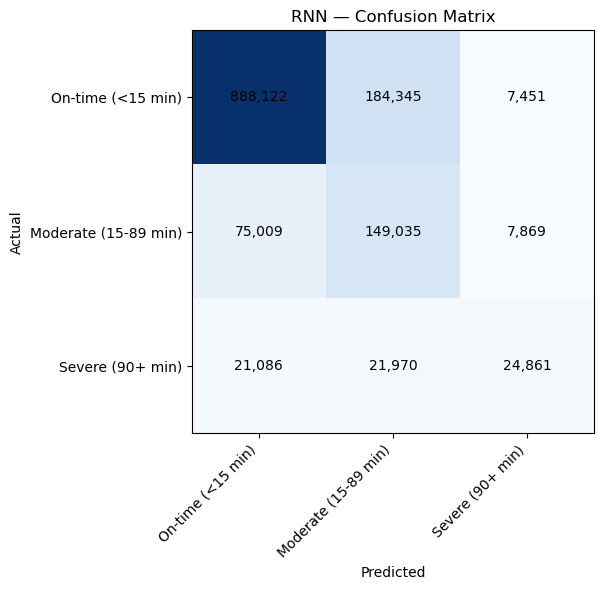

In [30]:
class RNNWrapper:
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        probabilities = self.model.predict(X, verbose=0)
        return probabilities.argmax(axis=1)

    def predict_proba(self, X):
        return self.model.predict(X, verbose=0)


rnn_wrapper = RNNWrapper(rnn_model)
results.append(evaluate("RNN", rnn_wrapper, X_test_rnn, y_test))


---
# Compare all models

In [31]:
comparison = pd.DataFrame(results).set_index("Model")
comparison.round(4)


,Accuracy,F1 (macro),Precision (macro),Recall (macro),F1 (weighted),AUC-ROC
Model,,,,,,
Logistic Regression,0.7128,0.5542,0.5495,0.5841,0.7365,0.7857
Random Forest,0.7592,0.6064,0.6140,0.6212,0.7741,0.8123
XGBoost,0.7709,0.6017,0.5873,0.6256,0.7824,0.8157
Naive Bayes,0.7340,0.5610,0.5547,0.5795,0.7500,0.7641
RNN,0.7697,0.6094,0.6468,0.6104,0.7815,0.8171


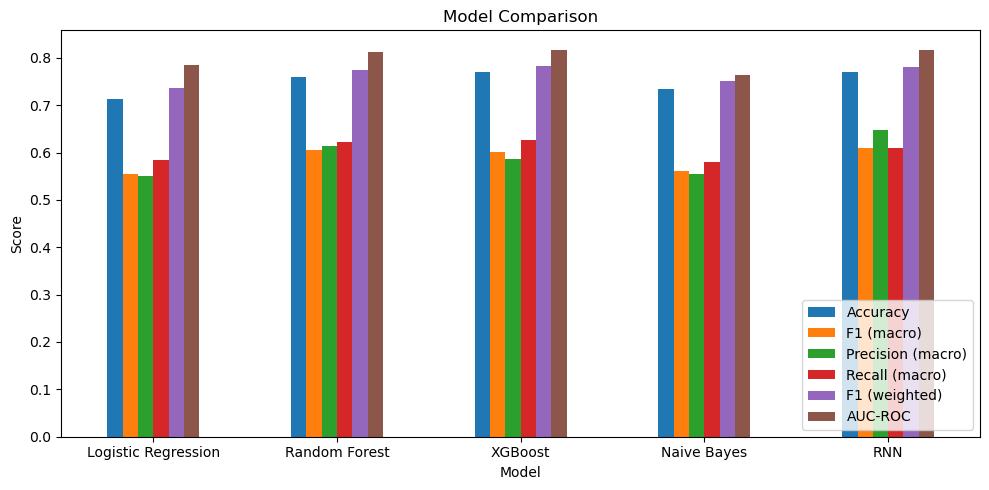

In [32]:
comparison.plot.bar(figsize=(10, 5), title="Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [33]:
pd.read_parquet("combined_preprocessed_weather.parquet")


,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,DEP_DELAY,DEP_DEL15,CRS_ELAPSED_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,...,HAS_PREV_FLIGHT,AIRPORT_TRAFFIC,IS_HOLIDAY,WX_TEMP,WX_RHUM,WX_PRCP,WX_WSPD,WX_PRES,WX_CLDC,WX_CODE
0,1,1,3,G4,-5.0,0.0,199.0,1334.0,NaN,NaN,...,0,9,1,21.1,90,0.0,7.6,1016.0,4,3
1,1,1,3,G4,-3.0,0.0,223.0,1334.0,NaN,NaN,...,1,1,1,0.0,0,0.0,0.0,0.0,0,0
2,1,2,4,G4,-3.0,0.0,148.0,865.0,NaN,NaN,...,0,9,1,17.8,84,0.0,9.4,1020.0,0,2
3,1,2,4,G4,-9.0,0.0,147.0,865.0,NaN,NaN,...,1,4,1,0.0,0,0.0,0.0,0.0,0,0
4,1,2,4,G4,-4.0,0.0,120.0,643.0,NaN,NaN,...,1,9,1,16.7,75,0.0,11.2,1021.5,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6898732,12,29,1,B6,31.0,1.0,252.0,1674.0,7.0,0.0,...,1,7,0,26.0,65,0.0,13.0,1016.0,2,2
6898733,12,30,2,B6,34.0,1.0,217.0,1237.0,7.0,0.0,...,0,11,0,-3.0,41,0.0,39.0,998.0,8,3
6898734,12,30,2,B6,34.0,1.0,171.0,1069.0,12.0,0.0,...,1,9,0,16.0,42,0.0,19.0,1017.0,2,2
6898735,12,31,3,B6,-4.0,0.0,190.0,1069.0,NaN,NaN,...,0,7,0,-3.0,42,0.0,30.0,1010.0,6,2
